# Optimisation results analysis
Comparing different runs - as of 09.04.2026 based on different input data used

- base anomaly calculation
- smoothed dataset using IDW
- aggregated rasters (for lower spatial resolution)

Includes:

- Selection frequency map
- Pareto front graph
- Parallel coordinates plot
- spatial similarity analysis (jaccard similarity -- objective similarity)

In [17]:
## ── 1. Imports ──────────────────────────────────────────────────────────

from pathlib import Path
import os
import sys
import pickle
import warnings
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from contextlib import contextmanager
from matplotlib.colors import ListedColormap

from itertools import combinations

try:
    from scipy.spatial.distance import cdist
except Exception:
    cdist = None

# Optional, but used by the original workflow
try:
    from pymoo.indicators.hv import HV
    from pymoo.util.callback import Callback
except Exception:
    HV = None

    class Callback:
        pass

import visualisations
from visualisations import (
    create_selection_frequency_map,
    plot_pareto_front,
    plot_parallel_coordinates,
)
from analyze_spatial_agreement import analyze_spatial_agreement
from patch_approach import convert_patch_results_to_pixel_decisions


In [18]:
## ── 2. Configuration ──────────────────────────────────────────────────────────

PROJECT_ROOT = Path(".")

# Specific runs to load for plotting and side-by-side comparison
RUN_PKL_A = PROJECT_ROOT / "results_files/res_fg_20260409_1647_nsga3_base.pkl"
RUN_PKL_B = PROJECT_ROOT / "results_files/res_fg_20260416_1247_cost_corrected_noWS.pkl"
RUN_PKL_C = PROJECT_ROOT / "results_files/res_fg_20260415_1840_cost_corrected.pkl"

#results_files/res_fg_20260409_1516_nsga3_agg.pkl
# Labels used in plot titles and output file names
RUN_LABEL_A = "Base"
RUN_LABEL_B = "Smoothed with IDW"
RUN_LABEL_C = "Aggregated"

# Set any RUN_PKL to None to skip that run
RUN_CONFIGS = [
    {"label": RUN_LABEL_A, "pkl": RUN_PKL_A},
    {"label": RUN_LABEL_B, "pkl": RUN_PKL_B},
    {"label": RUN_LABEL_C, "pkl": RUN_PKL_C},
]

# Ecosystem label, used in titles and in the Jaccard analysis
ECOSYSTEM = "fg"

# Set to True if run files contain patch based results that need conversion
USE_PATCH_APPROACH = False

# Directory to save figures and tables
OUTPUT_DIR = PROJECT_ROOT / "notebook_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Jaccard similarity analysis mode
# -----------------------------------------------------------------------------

# Choose one:
#   "between_seeds"      -> compare solutions across repeated runs with different seeds
#   "within_run_pareto"  -> compare Pareto optimal solutions within the loaded run
JACCARD_MODE = "within_run_pareto"

# Choose which loaded run to use for Jaccard when multiple runs are configured
JACCARD_RUN_LABEL = RUN_LABEL_A

# -----------------------------------------------------------------------------
# Between-seeds Jaccard settings
# -----------------------------------------------------------------------------

# These reproduce the Quarto workflow for spatial agreement analysis
FILE_DATE = "1703"
FILE_START = 11
FILE_END = 20
K_NEIGHBORS = 5

# -----------------------------------------------------------------------------
# Within-run Pareto Jaccard settings
# -----------------------------------------------------------------------------

# If True, use only non dominated solutions from the loaded run.
# If False, use every solution in the loaded run.
USE_ONLY_PARETO_SOLUTIONS = True

# Add project root to Python path
project_root_str = str(PROJECT_ROOT.resolve())
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"Project root:  {PROJECT_ROOT.resolve()}")
print(f"Output dir:    {OUTPUT_DIR.resolve()}")
print(f"Jaccard mode:  {JACCARD_MODE}")
print(f"Jaccard run:   {JACCARD_RUN_LABEL}")
for cfg in RUN_CONFIGS:
    if cfg["pkl"] is not None:
        print(f"{cfg['label']}: {cfg['pkl']}")


Project root:  C:\Users\inicholson\Documents\rest_prio
Output dir:    C:\Users\inicholson\Documents\rest_prio\notebook_outputs
Jaccard mode:  within_run_pareto
Jaccard run:   Base
Base: results_files\res_fg_20260409_1647_nsga3_base.pkl
Smoothed with IDW: results_files\res_fg_20260416_1247_cost_corrected_noWS.pkl
Aggregated: results_files\res_fg_20260415_1840_cost_corrected.pkl


In [19]:
## ── 3. Helper functions/classes ──────────────────────────────────────────────────────────

class HVCallback(Callback):
    def __init__(self, ref_point=None):
        super().__init__()
        self.ref_point = ref_point
        self.hv = HV(ref_point=ref_point) if HV is not None and ref_point is not None else None
        self.history = []

    def notify(self, algorithm):
        if self.hv is not None:
            hv_value = self.hv.do(algorithm.pop.get("F"))
            self.history.append(hv_value)


class SafeUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if name == "HVCallback":
            return HVCallback
        try:
            return super().find_class(module, name)
        except (ImportError, AttributeError) as e:
            warnings.warn(f"Could not import {module}.{name}, using dummy class: {e}")

            class DummyClass:
                def __init__(self, *args, **kwargs):
                    pass

            return DummyClass


def safe_pickle_load(file_path):
    file_path = Path(file_path)
    with open(file_path, "rb") as f:
        return SafeUnpickler(f).load()


#for plotting, to avoid plots being shown before they are called
@contextmanager
def _suppress_matplotlib_show():
    original_show = plt.show
    try:
        plt.show = lambda *args, **kwargs: None
        yield
    finally:
        plt.show = original_show


In [20]:
# -----------------------------------------------------------------------------
# Imports from the optimisation project
# -----------------------------------------------------------------------------

# Force-reload the visualisations module to pick up recent changes
importlib.reload(visualisations)
from visualisations import (
    create_selection_frequency_map,
    plot_pareto_front,
    plot_parallel_coordinates,
)


# Patch visualisations.load_results so it also uses the safe unpickler
original_load_results = visualisations.load_results

def patched_load_results(pkl_path, scenario_id=None, for_plotting_all=False):
    # This custom loader is primarily for handling old/complex pickle files safely.
    # It calls the *original* load_results from the module to handle the logic,
    # but it uses a safe unpickler.
    
    # The actual logic of what to do with the data is in visualisations.py
    return original_load_results(pkl_path, scenario_id=scenario_id, for_plotting_all=for_plotting_all)

visualisations.load_results = patched_load_results

print("Project imports loaded and load_results patched.")


Project imports loaded and load_results patched.


In [21]:

# -----------------------------------------------------------------------------
# Load selected run(s) and convert patch decisions if needed
# -----------------------------------------------------------------------------

loaded_runs = []

for cfg in RUN_CONFIGS:
    run_label = cfg["label"]
    run_pkl = cfg["pkl"]

    if run_pkl is None:
        continue
    if not Path(run_pkl).exists():
        print(f"Skipping {run_label}: file not found -> {run_pkl}")
        continue

    one_results = safe_pickle_load(run_pkl)
    run_for_plotting = Path(run_pkl)

    print(f"\n=== {run_label} ===")
    if isinstance(one_results, dict):
        print("Top level result keys:")
        print(sorted(one_results.keys()))

        for key in ["decisions", "X", "decisions_pixels", "decisions_patches"]:
            if key in one_results and hasattr(one_results[key], "shape"):
                print(f"{key}: {one_results[key].shape}")

        if "patch_mappings" in one_results:
            print("Patch mappings detected.")
            if USE_PATCH_APPROACH:
                if convert_patch_results_to_pixel_decisions is None:
                    raise ImportError("patch_approach.convert_patch_results_to_pixel_decisions is not available.")
                one_results = convert_patch_results_to_pixel_decisions(one_results, one_results["patch_mappings"])
                run_for_plotting = OUTPUT_DIR / f"{Path(run_pkl).stem}_pixels.pkl"
                with open(run_for_plotting, "wb") as f:
                    pickle.dump(one_results, f)
                print(f"Converted patch decisions saved to: {run_for_plotting}")
    else:
        print(f"Loaded object type: {type(one_results)}")
        if hasattr(one_results, "X"):
            print(f"X shape: {one_results.X.shape}")

    print(f"Run used for plotting: {run_for_plotting}")
    loaded_runs.append({
        "label": run_label,
        "input_path": Path(run_pkl),
        "plot_path": Path(run_for_plotting),
        "results": one_results,
    })

if len(loaded_runs) == 0:
    raise ValueError("No valid run files were loaded. Check RUN_PKL_A / RUN_PKL_B in the configuration cell.")

# Keep backward-compatible names for downstream cells.
# "results" defaults to the first loaded run.
results = loaded_runs[0]["results"]
run_for_plotting = loaded_runs[0]["plot_path"]

matching_jaccard_runs = [run for run in loaded_runs if run["label"] == JACCARD_RUN_LABEL]
if len(matching_jaccard_runs) == 0:
    available_labels = [run["label"] for run in loaded_runs]
    raise ValueError(
        f"JACCARD_RUN_LABEL '{JACCARD_RUN_LABEL}' was not loaded. Available labels: {available_labels}"
    )

jaccard_run = matching_jaccard_runs[0]
results_for_jaccard = jaccard_run["results"]
print(f"\nJaccard analysis will use: {jaccard_run['label']}")



=== Base ===
Top level result keys:
['X_history_path', 'algorithm_info', 'decisions', 'hv_callback', 'initial_conditions', 'is_nondominated', 'mutation_diagnostics', 'n_nondominated_solutions', 'n_solutions', 'objective_names', 'objectives', 'objectives_normalized', 'objectives_raw', 'patch_mappings', 'problem_info', 'repair_diagnostics', 'run_config', 'run_label', 'scenario_params']
decisions: (45, 144927)
Patch mappings detected.
Run used for plotting: results_files\res_fg_20260409_1647_nsga3_base.pkl

=== Smoothed with IDW ===
Top level result keys:
['X_history_path', 'algorithm_info', 'decisions', 'hv_callback', 'initial_conditions', 'is_nondominated', 'mutation_diagnostics', 'n_nondominated_solutions', 'n_solutions', 'objective_names', 'objectives', 'objectives_normalized', 'objectives_raw', 'patch_mappings', 'problem_info', 'repair_diagnostics', 'run_config', 'run_label', 'scenario_params']
decisions: (45, 144928)
Patch mappings detected.
Run used for plotting: results_files\res

In [22]:
# -----------------------------------------------------------------------------
# Helper functions for robust Jaccard analysis
# -----------------------------------------------------------------------------

def extract_array_from_results(results_obj, candidates):
    if isinstance(results_obj, dict):
        for key in candidates:
            if key in results_obj and results_obj[key] is not None and np.size(results_obj[key]) > 0:
                return np.asarray(results_obj[key]), key
    else:
        for key in candidates:
            if hasattr(results_obj, key):
                value = getattr(results_obj, key)
                if value is not None and np.size(value) > 0:
                    return np.asarray(value), key
    return None, None


def extract_X_F(results_obj):
    X, x_key = extract_array_from_results(results_obj, ["X", "decisions_pixels", "decisions", "decisions_patches"])
    F, f_key = extract_array_from_results(results_obj, ["F", "objectives"])
    return X, F, x_key, f_key


def get_non_dominated_mask(F):
    F = np.asarray(F)
    n = F.shape[0]
    is_non_dominated = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_non_dominated[i]:
            continue
        dominates_i = np.all(F <= F[i], axis=1) & np.any(F < F[i], axis=1)
        is_non_dominated[dominates_i] = False
    return is_non_dominated


def jaccard_similarity_binary(x1, x2):
    x1 = np.asarray(x1).astype(bool)
    x2 = np.asarray(x2).astype(bool)
    union = np.logical_or(x1, x2).sum()
    if union == 0:
        return 0.0
    intersection = np.logical_and(x1, x2).sum()
    return float(intersection / union)


def pairwise_jaccard_similarity_matrix(X_binary):
    X_binary = np.asarray(X_binary).astype(bool)
    n = X_binary.shape[0]
    out = np.eye(n, dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            s = jaccard_similarity_binary(X_binary[i], X_binary[j])
            out[i, j] = s
            out[j, i] = s
    return out


def analyse_within_run_jaccard(results_obj, use_only_pareto=True):
    X, F, x_key, f_key = extract_X_F(results_obj)
    if X is None:
        raise ValueError("Could not extract a decision matrix from the loaded run.")
    if F is None:
        raise ValueError("Could not extract an objective matrix from the loaded run.")

    if X.shape[0] != F.shape[0]:
        raise ValueError(f"X and F row counts do not match: X {X.shape}, F {F.shape}")

    selected_mask = np.ones(X.shape[0], dtype=bool)
    if use_only_pareto:
        if 'is_nondominated' in results_obj:
            print("Using 'is_nondominated' flag from results.")
            selected_mask = results_obj['is_nondominated']
        else:
            print("Falling back to calculating non-dominated mask.")
            selected_mask = get_non_dominated_mask(F)

    X_sel = X[selected_mask]
    F_sel = F[selected_mask]

    X_binary = np.asarray(X_sel).astype(int)

    jaccard_matrix = pairwise_jaccard_similarity_matrix(X_binary)

    if cdist is None:
        obj_dist_matrix = np.full((F_sel.shape[0], F_sel.shape[0]), np.nan)
    else:
        obj_dist_matrix = cdist(F_sel, F_sel, metric="euclidean")

    pair_rows = []
    for i, j in combinations(range(X_binary.shape[0]), 2):
        pair_rows.append({
            "solution_i": i,
            "solution_j": j,
            "jaccard_similarity": float(jaccard_matrix[i, j]),
            "objective_distance": float(obj_dist_matrix[i, j]) if cdist is not None else np.nan,
        })

    pair_df = pd.DataFrame(pair_rows)

    summary_rows = []
    for i in range(X_binary.shape[0]):
        mask_i = (pair_df["solution_i"] == i) | (pair_df["solution_j"] == i)
        one_df = pair_df.loc[mask_i]
        if len(one_df) == 0:
            continue
        summary_rows.append({
            "solution_idx": i,
            "mean_jaccard": float(one_df["jaccard_similarity"].mean()),
            "std_jaccard": float(one_df["jaccard_similarity"].std(ddof=0)),
            "min_jaccard": float(one_df["jaccard_similarity"].min()),
            "max_jaccard": float(one_df["jaccard_similarity"].max()),
            "mean_obj_distance": float(one_df["objective_distance"].mean()) if "objective_distance" in one_df else np.nan,
        })

    summary_df = pd.DataFrame(summary_rows)

    metadata = {
        "decision_source": x_key,
        "objective_source": f_key,
        "n_total_solutions": int(X.shape[0]),
        "n_selected_solutions": int(X_sel.shape[0]),
        "used_only_pareto": bool(use_only_pareto),
    }

    return {
        "X_selected": X_sel,
        "F_selected": F_sel,
        "X_binary": X_binary,
        "jaccard_matrix": jaccard_matrix,
        "pair_df": pair_df,
        "summary_df": summary_df,
        "metadata": metadata,
    }


## Input rasters used for optimisation runs

In [23]:
def plot_raster_row(paths, title, ncols=3, cmap="viridis"):
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4), squeeze=False)
    axes = axes[0]

    for i, ax in enumerate(axes):
        if i < len(paths):
            with rasterio.open(paths[i]) as src:
                data = src.read(1)

            ax.imshow(data, cmap=cmap)
            ax.set_title(paths[i].split("/")[-1], fontsize=10)
        else:
            ax.axis("off")

        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()


*** Input rasters ***


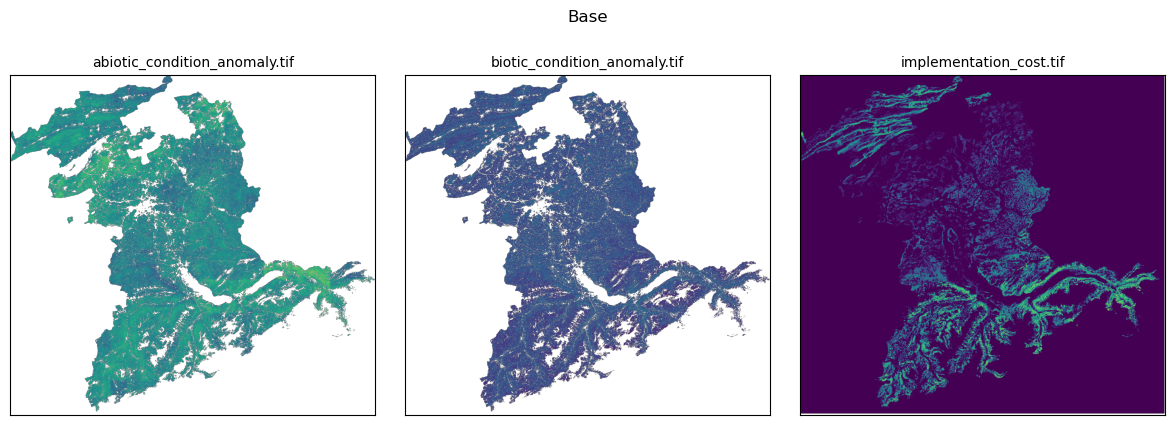

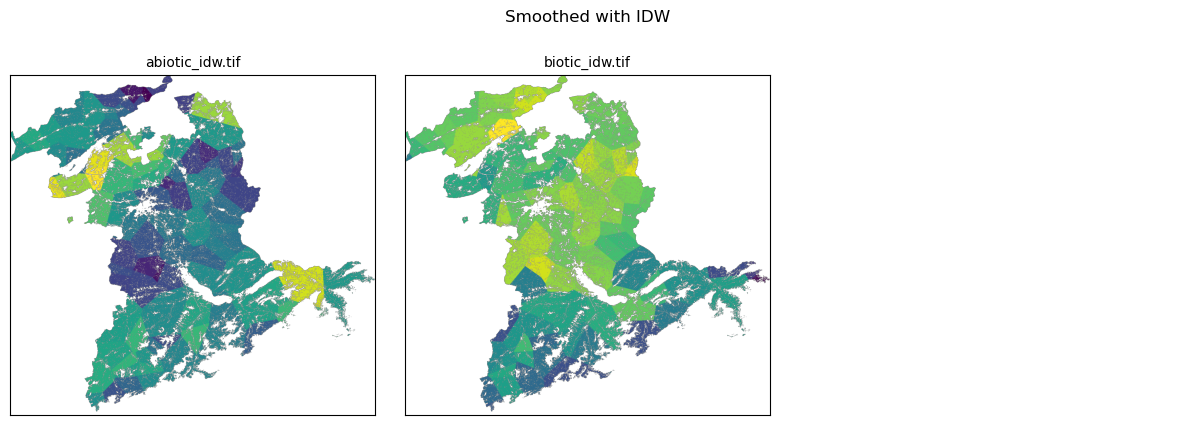

In [24]:
print("\n*** Input rasters ***")

row1 = [
    "inputs/abiotic_condition_anomaly.tif",
    "inputs/biotic_condition_anomaly.tif",
    "inputs/implementation_cost.tif"
]

row2 = [
    "inputs/abiotic_idw.tif",
    "inputs/biotic_idw.tif"
]


plot_raster_row(row1, "Base", ncols=3)
plot_raster_row(row2, "Smoothed with IDW", ncols=3)

In [25]:
# quickly calculate spatial correlation between the rasters

files = ["inputs/abiotic_condition_anomaly.tif", "inputs/biotic_condition_anomaly.tif", "inputs/implementation_cost.tif"]

# Read rasters
arrays = []
for f in files:
    with rasterio.open(f) as src:
        arr = src.read(1)
        arrays.append(arr)

# Valid pixels across all rasters
mask = np.logical_and.reduce([np.isfinite(arr) for arr in arrays])

# Stack valid values
stack = np.vstack([arr[mask] for arr in arrays])

# Correlation matrix
corr_matrix = np.corrcoef(stack)

print(corr_matrix)

# Correlation restricted to top 10% by combined rank (plausible Pareto pixels)
# stack shape: (3, n_valid_pixels) — rows: abiotic, biotic, cost

# Rank each objective (ascending = better for anomalies, descending for cost)
from scipy.stats import rankdata

ranks = np.vstack([
    rankdata(-stack[0]),  # abiotic: higher anomaly = better, so negate
    rankdata(-stack[1]),  # biotic: same
    rankdata(stack[2]),   # cost: lower = better, so ascending rank
])

# Combined rank = mean rank across objectives
combined_rank = ranks.mean(axis=0)

# Top 10% = lowest combined rank
threshold = np.percentile(combined_rank, 10)
top10_mask = combined_rank <= threshold

print(f"Top 10% subset: {top10_mask.sum()} pixels out of {stack.shape[1]}")

# Correlation within that subset
top10_stack = stack[:, top10_mask]
corr_top10 = np.corrcoef(top10_stack)

labels = ["abiotic", "biotic", "cost"]
print("\nCorrelation matrix (top 10% by combined rank):")
for i, li in enumerate(labels):
    for j, lj in enumerate(labels):
        if i < j:
            print(f"  {li} vs {lj}: {corr_top10[i, j]:.3f}")

# Compare to full eligible set
corr_full = np.corrcoef(stack)
print("\nCorrelation matrix (full eligible set):")
for i, li in enumerate(labels):
    for j, lj in enumerate(labels):
        if i < j:
            print(f"  {li} vs {lj}: {corr_full[i, j]:.3f}")

[[ 1.         -0.051714   -0.02668947]
 [-0.051714    1.          0.05952708]
 [-0.02668947  0.05952708  1.        ]]
Top 10% subset: 43711 pixels out of 437109

Correlation matrix (top 10% by combined rank):
  abiotic vs biotic: -0.344
  abiotic vs cost: 0.206
  biotic vs cost: 0.207

Correlation matrix (full eligible set):
  abiotic vs biotic: -0.052
  abiotic vs cost: -0.027
  biotic vs cost: 0.060


## Selection frequency comparison

Single scenario file detected.
Available keys: ['scenario_params', 'objective_names', 'objectives', 'objectives_raw', 'objectives_normalized', 'decisions', 'is_nondominated', 'n_solutions', 'n_nondominated_solutions', 'problem_info', 'algorithm_info', 'initial_conditions', 'hv_callback', 'run_label', 'run_config', 'repair_diagnostics', 'mutation_diagnostics', 'patch_mappings', 'X_history_path']
Filtering for non-dominated solutions.
Found 19 non-dominated solutions.
Loaded 19 Pareto-optimal solutions
Raster shape: (1131, 1215)
Eligible pixels: 362600
Decision vector shape: (19, 437102)
Calculating combined restoration + conversion frequency for separate pixel sets
Selection frequency range: 0.0% - 100.0%
Eligible pixels never selected: 387224 (88.6%)
✓ Selection frequency map saved to: notebook_outputs\selection_frequency_fg_base.png
Single scenario file detected.
Available keys: ['scenario_params', 'objective_names', 'objectives', 'objectives_raw', 'objectives_normalized', 'decisions'

C:\Users\inicholson\AppData\Local\Temp\ipykernel_33640\1153684559.py:156: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("YlOrRd")


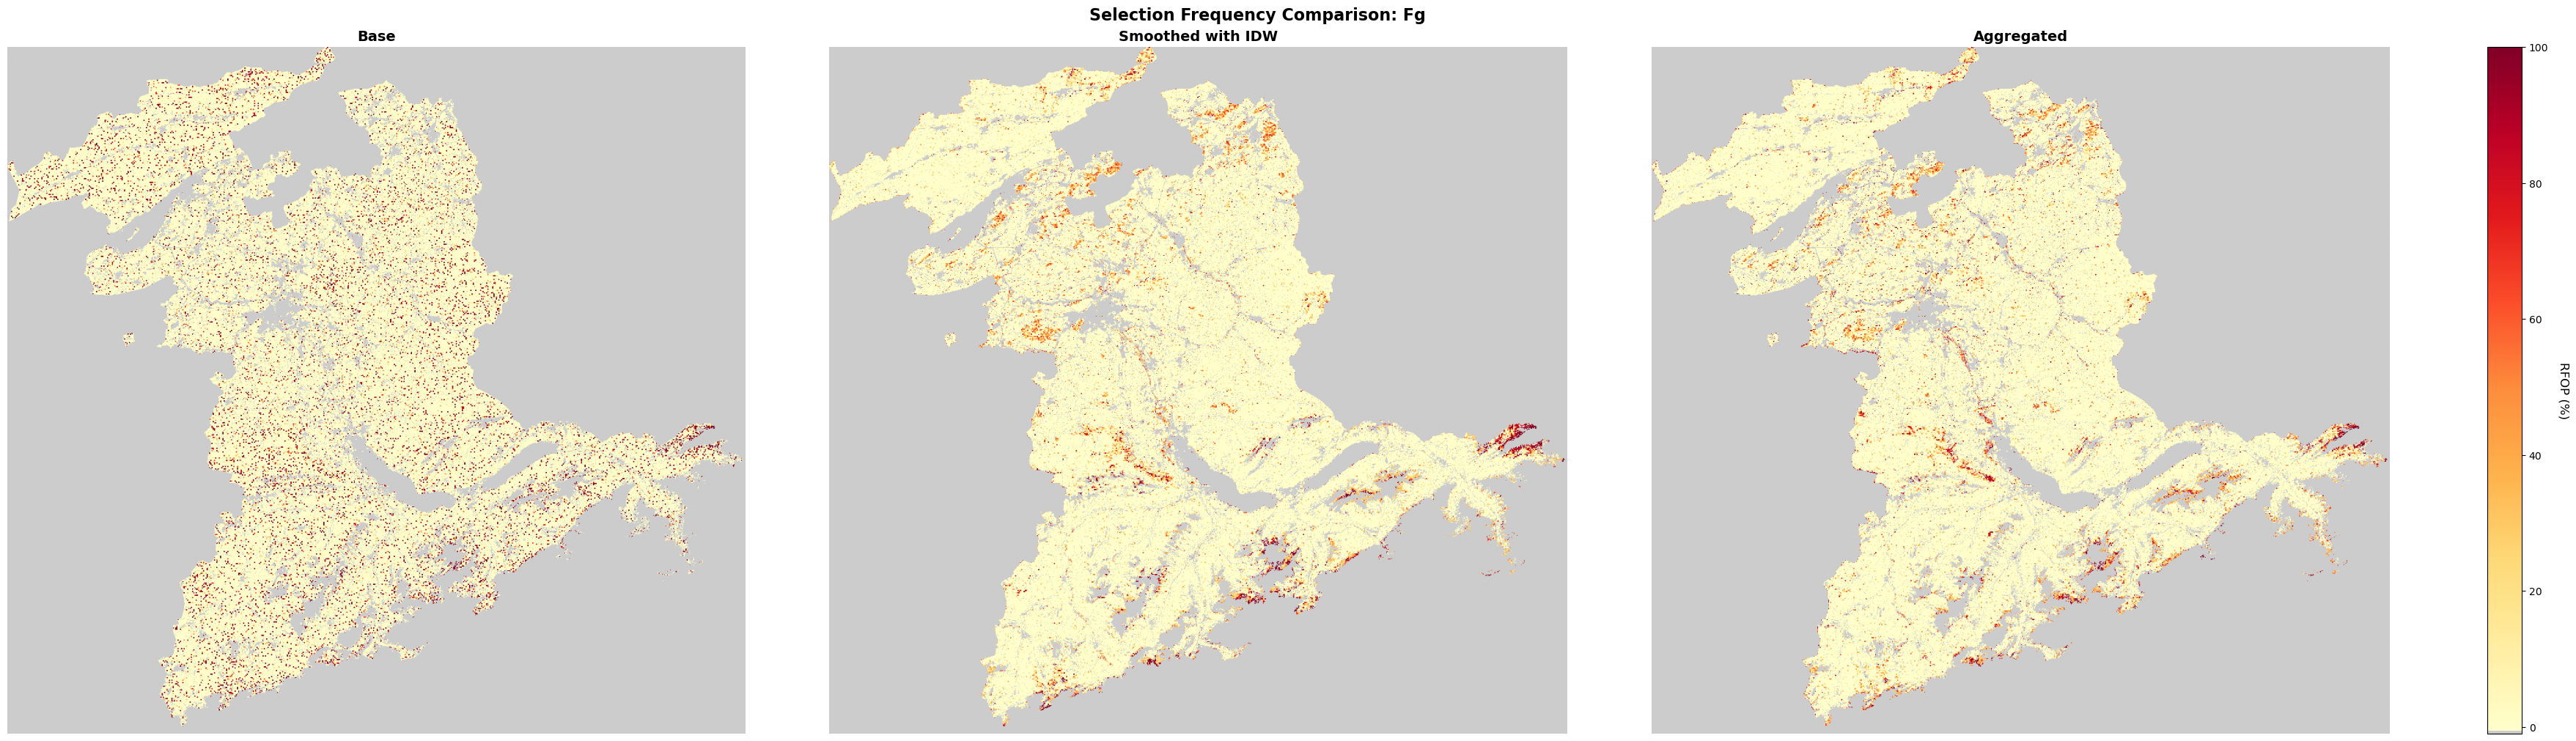

In [26]:
def _shift_slices(dr, dc):
    if dr >= 0:
        r1, r2 = slice(0, -dr if dr > 0 else None), slice(dr, None)
    else:
        r1, r2 = slice(-dr, None), slice(0, dr)

    if dc >= 0:
        c1, c2 = slice(0, -dc if dc > 0 else None), slice(dc, None)
    else:
        c1, c2 = slice(-dc, None), slice(0, dc)

    return r1, c1, r2, c2


def morans_i_queen(values_2d, valid_mask):
    values = np.asarray(values_2d, dtype=float)
    mask = np.asarray(valid_mask, dtype=bool)

    x = values[mask]
    n = x.size
    if n < 3:
        return np.nan, 0, n

    x_mean = x.mean()
    z = np.zeros_like(values, dtype=float)
    z[mask] = values[mask] - x_mean

    offsets = [(0, 1), (1, -1), (1, 0), (1, 1)]
    cross_sum = 0.0
    pair_count = 0

    for dr, dc in offsets:
        r1, c1, r2, c2 = _shift_slices(dr, dc)
        m1 = mask[r1, c1]
        m2 = mask[r2, c2]
        pair_mask = m1 & m2
        if not np.any(pair_mask):
            continue

        z1 = z[r1, c1][pair_mask]
        z2 = z[r2, c2][pair_mask]
        cross_sum += float(np.sum(z1 * z2))
        pair_count += int(np.sum(pair_mask))

    if pair_count == 0:
        return np.nan, 0, n

    s0 = 2 * pair_count
    numerator = 2 * cross_sum
    denominator = float(np.sum((x - x_mean) ** 2))

    if denominator == 0:
        return np.nan, s0, n

    i_value = (n / s0) * (numerator / denominator)
    return i_value, s0, n


selection_outputs = []
selection_paths = []

for run in loaded_runs:
    safe_label = run["label"].lower().replace(" ", "_")
    selection_path = OUTPUT_DIR / f"selection_frequency_{ECOSYSTEM}_{safe_label}.png"

    # Suppress individual plt.show() - we'll display side-by-side at the end
    with _suppress_matplotlib_show():
        selection_fig, _, selection_freq_map = create_selection_frequency_map(
            pkl_path=str(run["plot_path"]),
            save_path=str(selection_path),
            cmap="YlOrRd",
            title=f"Selection Frequency, {ECOSYSTEM.title()} ({run['label']})",
            action_type="combined",
            show_eligible=True,  # Use function's built-in grey rendering for non-eligible
        )
    plt.close(selection_fig)

    selection_paths.append(selection_path)
    
    # For stats: consider pixels with value >= 0 as eligible (function uses -1 for non-eligible when show_eligible=True)
    eligible_mask = (selection_freq_map >= 0)
    selected_mask = eligible_mask & (selection_freq_map > 0)

    run_stats = {
        "eligible_pixels": int(eligible_mask.sum()),
        "selected_pixels": int(selected_mask.sum()),
        "moran_i": np.nan,
        "expected_i": np.nan,
        "s0": 0,
        "q1": np.nan,
        "median": np.nan,
        "q3": np.nan,
        "interpretation": "No selected pixels found; spatial autocorrelation not available.",
    }

    if np.any(selected_mask):
        moran_i, s0, n = morans_i_queen(selection_freq_map, eligible_mask)
        expected_i = -1 / (n - 1) if n > 1 else np.nan

        if np.isnan(moran_i):
            interpretation = "Not estimable (insufficient variation or adjacency)."
        elif moran_i > 0.15:
            interpretation = "Positive autocorrelation (similar values cluster together)."
        elif moran_i < -0.15:
            interpretation = "Negative autocorrelation (checkerboard-like dispersion)."
        else:
            interpretation = "Weak autocorrelation (near-random spatial pattern)."

        selected_values = selection_freq_map[selected_mask]
        q1, median, q3 = np.percentile(selected_values, [25, 50, 75])

        run_stats.update({
            "moran_i": float(moran_i),
            "expected_i": float(expected_i),
            "s0": int(s0),
            "q1": float(q1),
            "median": float(median),
            "q3": float(q3),
            "interpretation": interpretation,
        })

    selection_outputs.append({
        "label": run["label"],
        "path": selection_path,
        "map": np.asarray(selection_freq_map),
        "stats": run_stats,
    })

# Print statistics for each run
for out in selection_outputs:
    stats = out["stats"]
    print(f"\nSelection-frequency spatial autocorrelation ({out['label']})")
    print(f"Saved map: {out['path']}")
    print(f"Eligible pixels used: {stats['eligible_pixels']}")
    print(f"Selected at least once: {stats['selected_pixels']}")
    if np.isnan(stats["moran_i"]):
        print("Moran's I (queen contiguity): not estimable")
    else:
        print(f"Moran's I (queen contiguity): {stats['moran_i']:.4f}")
        print(f"Expected I under spatial randomness: {stats['expected_i']:.4f}")
        print(f"Neighbour links used (S0): {stats['s0']}")
        print(
            "Selected-frequency quartiles (Q1 / median / Q3): "
            f"{stats['q1']:.1f}% / {stats['median']:.1f}% / {stats['q3']:.1f}%"
        )
    print(f"Interpretation: {stats['interpretation']}")

# Create side-by-side display using the function's custom colormap approach
if len(selection_outputs) > 0:
    n_cols = len(selection_outputs)
    fig, axes = plt.subplots(1, n_cols, figsize=(12 * n_cols, 10), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    # Create custom colormap matching the function's approach: grey for non-eligible, YlOrRd for frequencies
    base_cmap = plt.cm.get_cmap("YlOrRd")
    colors = ['#CCCCCC']  # Grey for non-eligible pixels (-1 value)
    colors.extend([base_cmap(i) for i in np.linspace(0, 1, 256)])
    custom_cmap = ListedColormap(colors)

    image_artist = None
    for ax, out in zip(axes, selection_outputs):
        # Plot with custom range: -1 to 100 (matching function's approach)
        frequency_map_plot = out["map"]
        im = ax.imshow(frequency_map_plot, cmap=custom_cmap, vmin=-1, vmax=100)
        ax.set_title(f"{out['label']}", fontsize=14, fontweight='bold')
        ax.axis('off')
        image_artist = im

    fig.suptitle(f"Selection Frequency Comparison: {ECOSYSTEM.title()}", fontsize=16, fontweight='bold')
    if image_artist is not None:
        cbar = fig.colorbar(image_artist, ax=axes, fraction=0.046, pad=0.04)
        cbar.set_label('RFOP (%)', rotation=270, labelpad=20, fontsize=12)
    
    plt.show()

## Jaccard similarity analysis

[between_seeds] compares solutions across repeated runs with different seeds, using the same workflow as the Quarto document.

[within_run_pareto] compares solutions within the currently loaded run, usually restricted to the Pareto optimal set.

In [27]:
agreement_df = None
agreement_csv = None
jaccard_pair_csv = None
jaccard_matrix_csv = None
jaccard_result = None

agreement_csv_paths = []
jaccard_pair_csv_paths = []
jaccard_matrix_csv_paths = []
jaccard_outputs = []

if JACCARD_MODE == "between_seeds":
    if analyze_spatial_agreement is None:
        raise ImportError("analyze_spatial_agreement is not available in this project.")

    suffix = "_patch" if USE_PATCH_APPROACH else "_pixel"
    agreement_csv = OUTPUT_DIR / f"spatial_agreement_{ECOSYSTEM}_{FILE_DATE}{suffix}.csv"

    if agreement_csv.exists():
        agreement_df = pd.read_csv(agreement_csv)
        source_msg = "loaded"
    else:
        agreement_df = analyze_spatial_agreement(
            ecosystem=ECOSYSTEM,
            file_date=FILE_DATE,
            file_start=FILE_START,
            file_end=FILE_END,
            k_neighbors=K_NEIGHBORS,
            use_patch_approach=USE_PATCH_APPROACH,
            output_file=str(agreement_csv),
        )
        source_msg = "computed"

    agreement_csv_paths.append(agreement_csv)
    jaccard_outputs.append({
        "label": "between_seeds",
        "summary_df": agreement_df.copy(),
        "pair_df": None,
        "result": None,
    })

    print(f"Jaccard ({JACCARD_MODE}): {source_msg} {len(agreement_df)} rows")
    print(f"Summary file: {agreement_csv}")

elif JACCARD_MODE == "within_run_pareto":
    for run in loaded_runs:
        one_result = analyse_within_run_jaccard(
            run["results"],
            use_only_pareto=USE_ONLY_PARETO_SOLUTIONS,
        )
        one_summary_df = one_result["summary_df"]

        safe_label = run["label"].lower().replace(" ", "_")
        stem = f"jaccard_within_run_{ECOSYSTEM}_{safe_label}"
        if USE_ONLY_PARETO_SOLUTIONS:
            stem += "_pareto"

        one_summary_csv = OUTPUT_DIR / f"{stem}_summary.csv"
        one_pair_csv = OUTPUT_DIR / f"{stem}_pairs.csv"
        one_matrix_csv = OUTPUT_DIR / f"{stem}_matrix.csv"

        one_summary_df.to_csv(one_summary_csv, index=False)
        one_result["pair_df"].to_csv(one_pair_csv, index=False)
        pd.DataFrame(one_result["jaccard_matrix"]).to_csv(one_matrix_csv, index=False)

        agreement_csv_paths.append(one_summary_csv)
        jaccard_pair_csv_paths.append(one_pair_csv)
        jaccard_matrix_csv_paths.append(one_matrix_csv)
        jaccard_outputs.append({
            "label": run["label"],
            "summary_df": one_summary_df.copy(),
            "pair_df": one_result["pair_df"].copy(),
            "result": one_result,
        })

        metadata = one_result["metadata"]
        mean_jaccard = one_summary_df["mean_jaccard"].mean() if len(one_summary_df) > 0 else np.nan
        print(
            "Selected solutions: "
            f"{metadata['n_selected_solutions']}/{metadata['n_total_solutions']} "
            f"(pareto_only={metadata['used_only_pareto']})"
        )
        print(f"Mean per-solution Jaccard: {mean_jaccard:.3f}")
        #print(f"Summary file: {one_summary_csv}")
        #print(f"Pairwise file: {one_pair_csv}")
        #print(f"Matrix file: {one_matrix_csv}")

    if len(jaccard_outputs) == 0:
        raise ValueError("No loaded runs available for within-run Jaccard analysis.")

    agreement_df = pd.concat(
        [out["summary_df"].assign(run_label=out["label"]) for out in jaccard_outputs],
        ignore_index=True,
    )

    # Backward-compatible single-value variables for downstream cells
    agreement_csv = agreement_csv_paths[0] if len(agreement_csv_paths) > 0 else None
    jaccard_pair_csv = jaccard_pair_csv_paths[0] if len(jaccard_pair_csv_paths) > 0 else None
    jaccard_matrix_csv = jaccard_matrix_csv_paths[0] if len(jaccard_matrix_csv_paths) > 0 else None
    jaccard_result = jaccard_outputs[0]["result"]

else:
    raise ValueError("JACCARD_MODE must be either 'between_seeds' or 'within_run_pareto'.")

Using 'is_nondominated' flag from results.
Selected solutions: 19/45 (pareto_only=True)
Mean per-solution Jaccard: 0.749
Using 'is_nondominated' flag from results.
Selected solutions: 16/45 (pareto_only=True)
Mean per-solution Jaccard: 0.348
Using 'is_nondominated' flag from results.
Selected solutions: 16/45 (pareto_only=True)
Mean per-solution Jaccard: 0.386


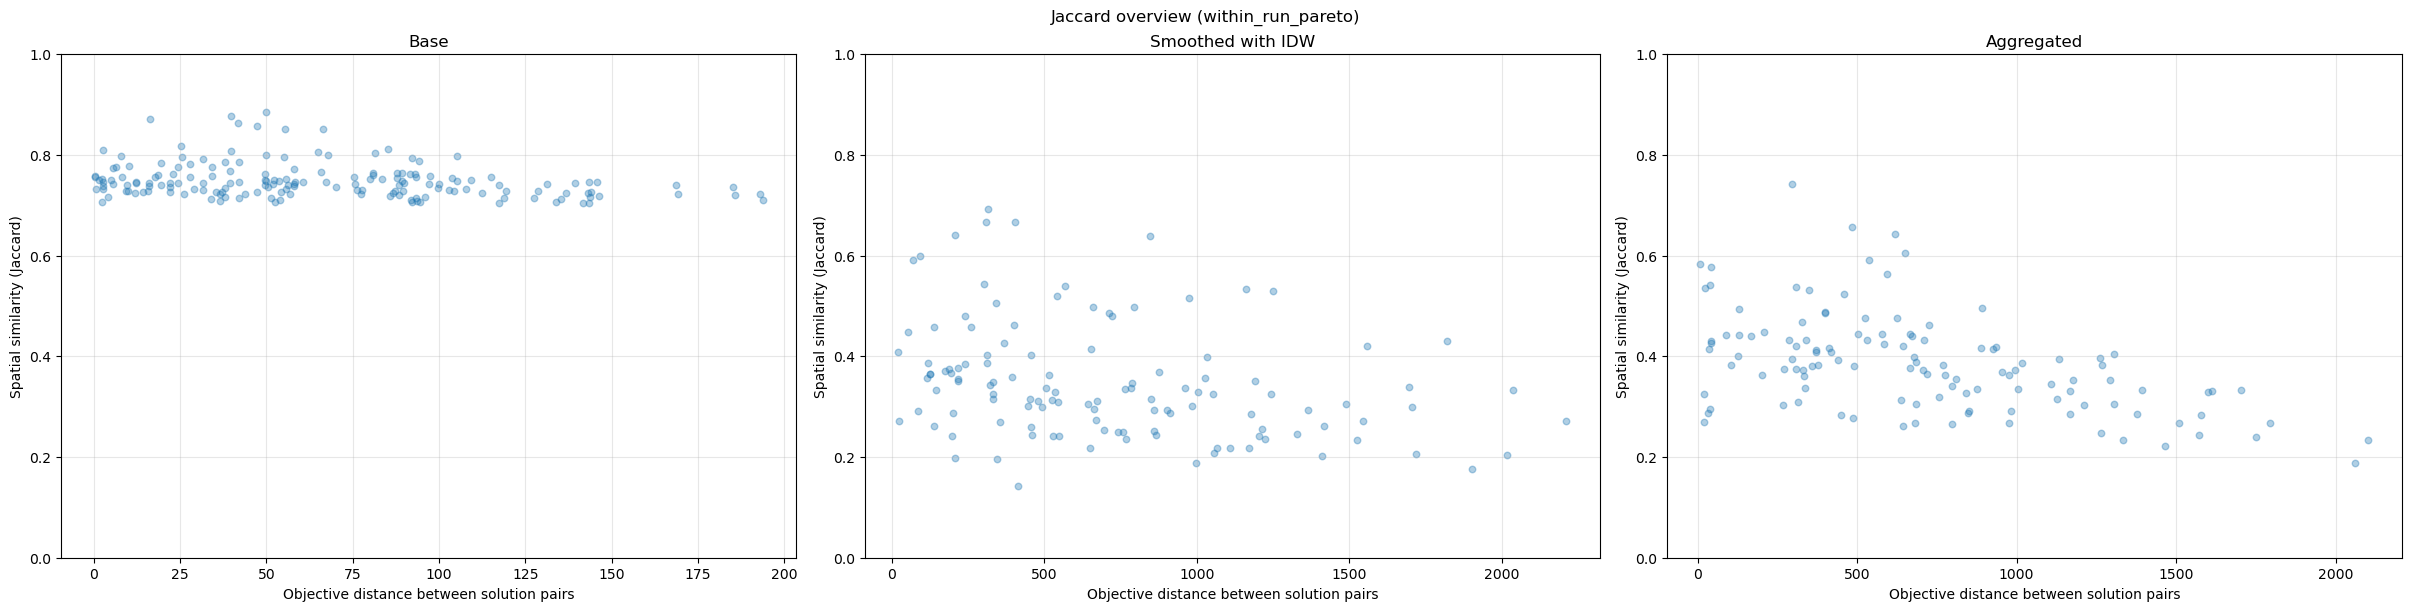


Jaccard overview stats (Base)
Points used: 171
Objective distance (min / Q1 / median / Q3 / max): 0.287 / 27.848 / 55.582 / 93.376 / 193.723
Jaccard similarity (min / Q1 / median / Q3 / max): 0.704 / 0.727 / 0.743 / 0.760 / 0.885
Pearson correlation (distance vs similarity):  -0.267
Spearman correlation (distance vs similarity): -0.281

Jaccard overview stats (Smoothed with IDW)
Points used: 120
Objective distance (min / Q1 / median / Q3 / max): 21.078 / 313.805 / 647.249 / 1028.052 / 2212.078
Jaccard similarity (min / Q1 / median / Q3 / max): 0.143 / 0.262 / 0.328 / 0.400 / 0.693
Pearson correlation (distance vs similarity):  -0.316
Spearman correlation (distance vs similarity): -0.367

Jaccard overview stats (Aggregated)
Points used: 120
Objective distance (min / Q1 / median / Q3 / max): 9.208 / 334.395 / 647.587 / 985.376 / 2101.777
Jaccard similarity (min / Q1 / median / Q3 / max): 0.187 / 0.315 / 0.381 / 0.433 / 0.743
Pearson correlation (distance vs similarity):  -0.516
Spearman

In [28]:
if len(jaccard_outputs) > 0:
    plot_items = []

    for out in jaccard_outputs:
        if JACCARD_MODE == "within_run_pareto" and out["pair_df"] is not None and len(out["pair_df"]) > 0:
            plot_df = out["pair_df"][["objective_distance", "jaccard_similarity"]].dropna().copy()
            x_col = "objective_distance"
            y_col = "jaccard_similarity"
            x_label = "Objective distance between solution pairs"
            y_label = "Spatial similarity (Jaccard)"
            title = out["label"]
        else:
            if "mean_obj_distance" not in out["summary_df"].columns or "mean_jaccard" not in out["summary_df"].columns:
                continue
            plot_df = out["summary_df"][["mean_obj_distance", "mean_jaccard"]].dropna().copy()
            x_col = "mean_obj_distance"
            y_col = "mean_jaccard"
            x_label = "Mean objective distance"
            y_label = "Mean spatial similarity (Jaccard)"
            title = out["label"]

        if len(plot_df) == 0:
            continue

        plot_items.append({
            "label": out["label"],
            "plot_df": plot_df,
            "x_col": x_col,
            "y_col": y_col,
            "x_label": x_label,
            "y_label": y_label,
            "title": title,
        })

    if len(plot_items) == 0:
        print("No valid objective-distance/Jaccard pairs to plot.")
    else:
        n_cols = len(plot_items)
        fig, axes = plt.subplots(1, n_cols, figsize=(8 * n_cols, 6), constrained_layout=True)
        if n_cols == 1:
            axes = [axes]

        for ax, item in zip(axes, plot_items):
            plot_df = item["plot_df"]
            ax.scatter(plot_df[item["x_col"]], plot_df[item["y_col"]], alpha=0.35, s=22, color="tab:blue")
            ax.set_xlabel(item["x_label"])
            ax.set_ylabel(item["y_label"])
            ax.set_title(item["title"])
            ax.set_ylim(0, 1)
            ax.grid(True, alpha=0.3)

        fig.suptitle(f"Jaccard overview ({JACCARD_MODE})")
        plt.show()

        for item in plot_items:
            plot_df = item["plot_df"]
            n = len(plot_df)
            x_stats = plot_df[item["x_col"]].describe(percentiles=[0.25, 0.5, 0.75])
            y_stats = plot_df[item["y_col"]].describe(percentiles=[0.25, 0.5, 0.75])
            pearson_r = plot_df[item["x_col"]].corr(plot_df[item["y_col"]], method="pearson")
            spearman_r = plot_df[item["x_col"]].corr(plot_df[item["y_col"]], method="spearman")

            print(f"\nJaccard overview stats ({item['label']})")
            print(f"Points used: {n}")
            print(
                f"Objective distance (min / Q1 / median / Q3 / max): "
                f"{x_stats['min']:.3f} / {x_stats['25%']:.3f} / {x_stats['50%']:.3f} / {x_stats['75%']:.3f} / {x_stats['max']:.3f}"
            )
            print(
                f"Jaccard similarity (min / Q1 / median / Q3 / max): "
                f"{y_stats['min']:.3f} / {y_stats['25%']:.3f} / {y_stats['50%']:.3f} / {y_stats['75%']:.3f} / {y_stats['max']:.3f}"
            )
            print(f"Pearson correlation (distance vs similarity):  {pearson_r:.3f}")
            print(f"Spearman correlation (distance vs similarity): {spearman_r:.3f}")
else:
    print("No Jaccard analysis results available.")

## Pareto front comparison

Single scenario file detected.
Available keys: ['scenario_params', 'objective_names', 'objectives', 'objectives_raw', 'objectives_normalized', 'decisions', 'is_nondominated', 'n_solutions', 'n_nondominated_solutions', 'problem_info', 'algorithm_info', 'initial_conditions', 'hv_callback', 'run_label', 'run_config', 'repair_diagnostics', 'mutation_diagnostics', 'patch_mappings', 'X_history_path']
Filtering for non-dominated solutions.
Found 19 non-dominated solutions.
Single scenario file detected.
Available keys: ['scenario_params', 'objective_names', 'objectives', 'objectives_raw', 'objectives_normalized', 'decisions', 'is_nondominated', 'n_solutions', 'n_nondominated_solutions', 'problem_info', 'algorithm_info', 'initial_conditions', 'hv_callback', 'run_label', 'run_config', 'repair_diagnostics', 'mutation_diagnostics', 'patch_mappings', 'X_history_path']
✓ Saved pareto front to: notebook_outputs\pareto_front_fg_base.png
Saved Pareto front figure (Base) to: notebook_outputs\pareto_fro

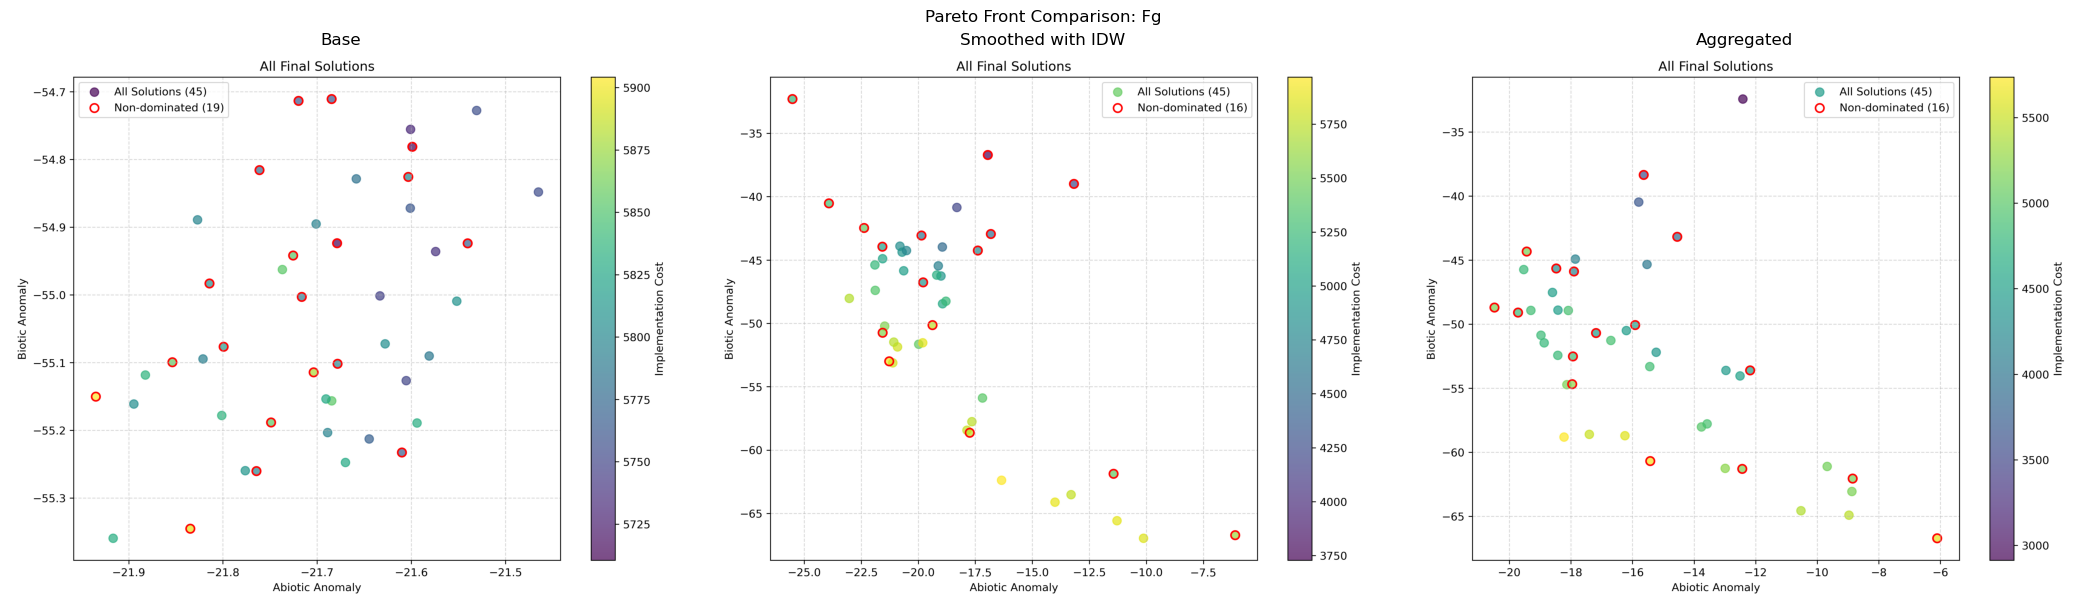

In [29]:
pareto_outputs = []
pareto_paths = []

for run in loaded_runs:
    safe_label = run["label"].lower().replace(" ", "_")
    pareto_path = OUTPUT_DIR / f"pareto_front_{ECOSYSTEM}_{safe_label}.png"

    with _suppress_matplotlib_show():
        pareto_fig = plot_pareto_front(
            pkl_path=str(run["plot_path"]),
            save_path=str(pareto_path),
            figsize=(10, 8),
            alpha=0.7,
            show_all_solutions=True,
        )
    plt.close(pareto_fig)

    pareto_paths.append(pareto_path)
    pareto_outputs.append({
        "label": run["label"],
        "path": pareto_path,
    })
    print(f"Saved Pareto front figure ({run['label']}) to: {pareto_path}")

if len(pareto_outputs) > 0:
    n_cols = len(pareto_outputs)
    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    for ax, out in zip(axes, pareto_outputs):
        img = plt.imread(out["path"])
        ax.imshow(img)
        ax.set_title(out["label"])
        ax.axis("off")

    fig.suptitle(f"Pareto Front Comparison: {ECOSYSTEM.title()}")
    plt.show()


## Parallel coordinates comparison

Single scenario file detected.
Available keys: ['scenario_params', 'objective_names', 'objectives', 'objectives_raw', 'objectives_normalized', 'decisions', 'is_nondominated', 'n_solutions', 'n_nondominated_solutions', 'problem_info', 'algorithm_info', 'initial_conditions', 'hv_callback', 'run_label', 'run_config', 'repair_diagnostics', 'mutation_diagnostics', 'patch_mappings', 'X_history_path']
Parallelization enabled with 24 processes
Plotting parallel coordinates: 45 solutions total (19 non-dominated, 26 dominated)
✓ Parallel coordinates plot saved to: notebook_outputs\parallel_coordinates_fg_base.png
Single scenario file detected.
Available keys: ['scenario_params', 'objective_names', 'objectives', 'objectives_raw', 'objectives_normalized', 'decisions', 'is_nondominated', 'n_solutions', 'n_nondominated_solutions', 'problem_info', 'algorithm_info', 'initial_conditions', 'hv_callback', 'run_label', 'run_config', 'repair_diagnostics', 'mutation_diagnostics', 'patch_mappings', 'X_histor

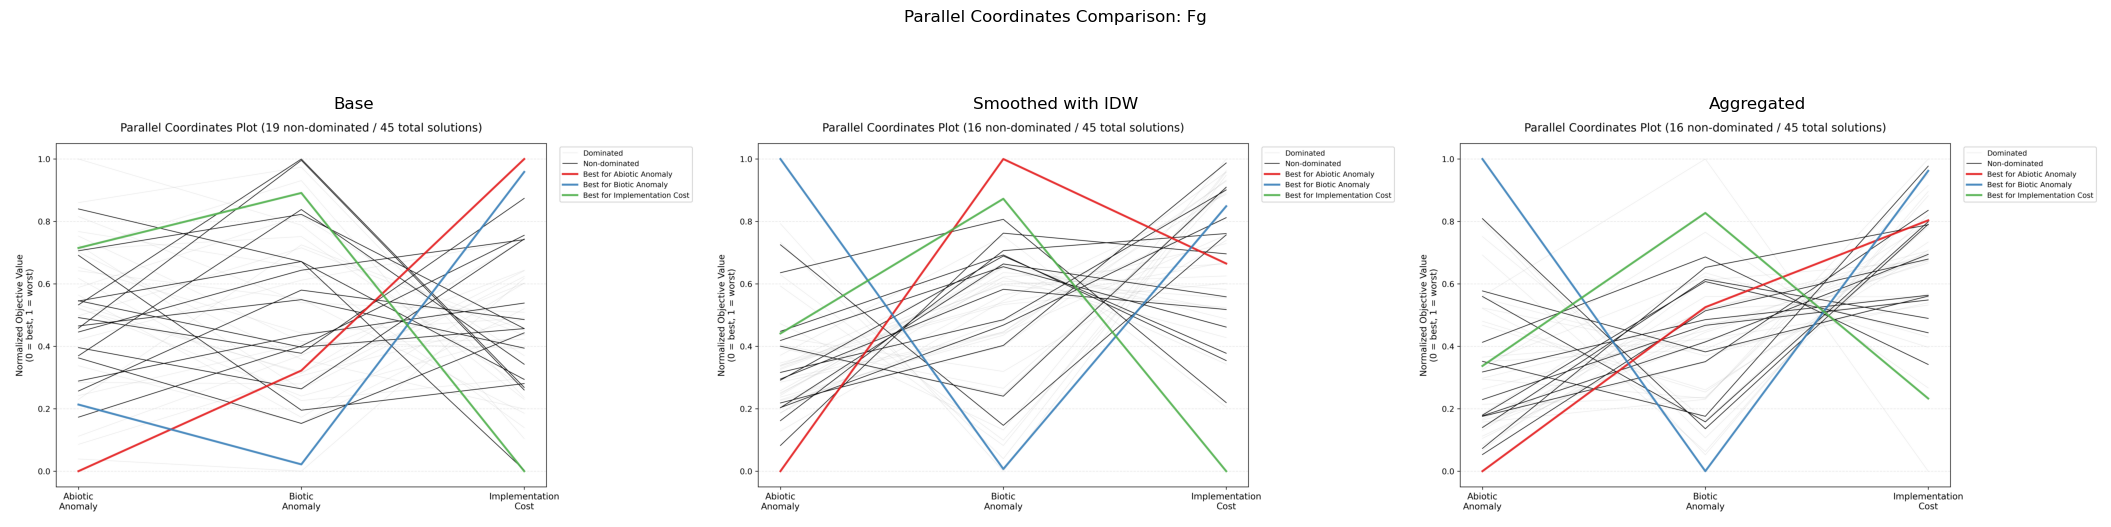

In [30]:
parallel_outputs = []
parallel_paths = []

for run in loaded_runs:
    safe_label = run["label"].lower().replace(" ", "_")
    parallel_path = OUTPUT_DIR / f"parallel_coordinates_{ECOSYSTEM}_{safe_label}.png"

    with _suppress_matplotlib_show():
        parallel_fig = plot_parallel_coordinates(
            pkl_path=str(run["plot_path"]),
            save_path=str(parallel_path),
            figsize=(12, 7),
            alpha_background=0.15,
        )
    plt.close(parallel_fig)

    parallel_paths.append(parallel_path)
    parallel_outputs.append({
        "label": run["label"],
        "path": parallel_path,
    })

if len(parallel_outputs) > 0:
    n_cols = len(parallel_outputs)
    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    for ax, out in zip(axes, parallel_outputs):
        img = plt.imread(out["path"])
        ax.imshow(img)
        ax.set_title(out["label"])
        ax.axis("off")

    fig.suptitle(f"Parallel Coordinates Comparison: {ECOSYSTEM.title()}")
    plt.show()

Single scenario file detected.
Available keys: ['scenario_params', 'objective_names', 'objectives', 'objectives_raw', 'objectives_normalized', 'decisions', 'is_nondominated', 'n_solutions', 'n_nondominated_solutions', 'problem_info', 'algorithm_info', 'initial_conditions', 'hv_callback', 'run_label', 'run_config', 'repair_diagnostics', 'mutation_diagnostics', 'patch_mappings', 'X_history_path']
Filtering for non-dominated solutions.
Found 19 non-dominated solutions.
Single scenario file detected.
Available keys: ['scenario_params', 'objective_names', 'objectives', 'objectives_raw', 'objectives_normalized', 'decisions', 'is_nondominated', 'n_solutions', 'n_nondominated_solutions', 'problem_info', 'algorithm_info', 'initial_conditions', 'hv_callback', 'run_label', 'run_config', 'repair_diagnostics', 'mutation_diagnostics', 'patch_mappings', 'X_history_path']
Filtering for non-dominated solutions.
Found 16 non-dominated solutions.
Single scenario file detected.
Available keys: ['scenario_

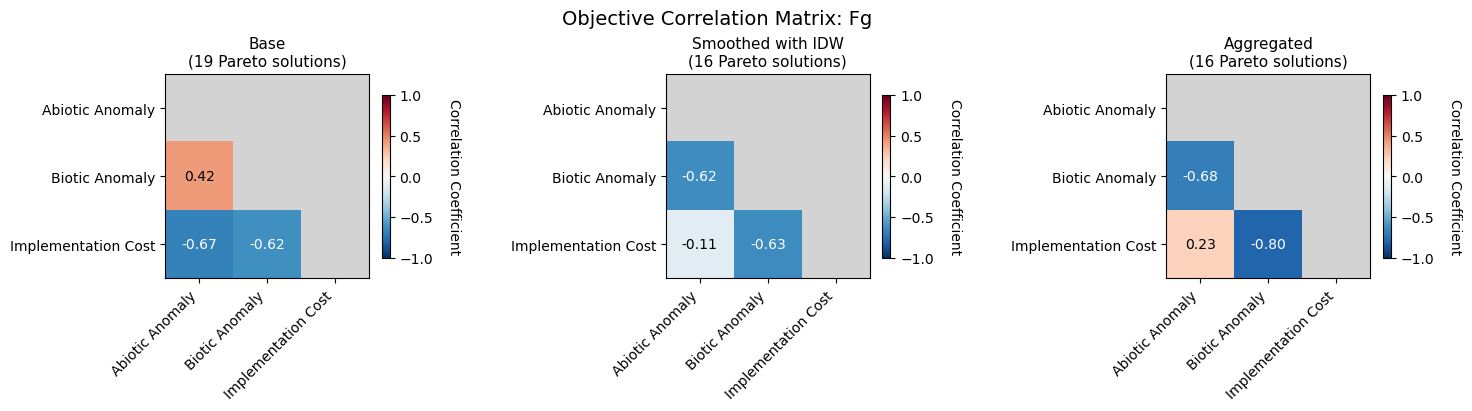

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from visualisations import load_results

n_cols = len(loaded_runs)
fig, axes = plt.subplots(
    1,
    n_cols,
    figsize=(max(5, 5 * n_cols), 4),
    constrained_layout=True
)

if n_cols == 1:
    axes = [axes]

for ax, run in zip(axes, loaded_runs):
    run_results = load_results(str(run["plot_path"]))
    obj_names = run_results.get(
        "objective_names",
        [f"obj_{i}" for i in range(run_results["objectives"].shape[1])]
    )

    df_obj = pd.DataFrame(run_results["objectives"], columns=obj_names)
    corr = df_obj.corr()
    corr_values = corr.values

    # Mask upper triangle + diagonal
    mask = np.triu(np.ones_like(corr_values, dtype=bool))
    corr_plot = np.ma.masked_where(mask, corr_values)

    # Plot lower triangle only
    im = ax.imshow(corr_plot, cmap="RdBu_r", vmin=-1, vmax=1)

    # Grey background for masked cells
    ax.set_facecolor("lightgrey")

    # Axis labels
    ax.set_xticks(range(len(obj_names)))
    ax.set_yticks(range(len(obj_names)))
    ax.set_xticklabels(
        [n.replace("_", " ").title() for n in obj_names],
        rotation=45,
        ha="right"
    )
    ax.set_yticklabels(
        [n.replace("_", " ").title() for n in obj_names]
    )

    # Add text only to lower triangle
    for i in range(len(obj_names)):
        for j in range(len(obj_names)):
            if i > j:
                val = corr.iloc[i, j]
                ax.text(
                    j, i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    color="white" if abs(val) > 0.5 else "black",
                    fontsize=10
                )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Correlation Coefficient", rotation=270, labelpad=20)

    ax.set_title(
        f"{run['label']}\n({len(df_obj):,} Pareto solutions)",
        fontsize=11
    )

fig.suptitle(f"Objective Correlation Matrix: {ECOSYSTEM.title()}", fontsize=14)
plt.show()


In [32]:
# Load the temp=0.5 run and check cost spread
import pickle
with open("results_files/res_fg_20260413_1943_mutation_100_frac0.2_patchtemp5.0.pkl", "rb") as f:
    r = pickle.load(f)

F = r["objectives"]  # shape (n_solutions, 3)
obj_names = r.get("objective_names", ["abiotic", "biotic", "cost"])
print(pd.DataFrame(F, columns=obj_names).describe())

       abiotic_anomaly  biotic_anomaly  implementation_cost
count        45.000000       45.000000            45.000000
mean         -8.626175      -16.080110          1222.614662
std           0.292902        0.478871            34.172130
min          -9.231192      -16.885815          1147.614014
25%          -8.791931      -16.415878          1201.843384
50%          -8.666956      -16.175022          1216.386230
75%          -8.476229      -15.772070          1251.565186
max          -7.681805      -14.450273          1294.250000
